In [1]:
import scanpy as sc
import scvi
import numpy as np
import sys
sys.path.append('../')

from scripts.subset_hvg import subset_to_hvg

adata = sc.read_h5ad(
    "../../data/obesity_challenge_2.h5ad"
)

print(adata)

adata_subset, hvg_genes,sig_genes = subset_to_hvg(
    adata,
    hvg_path="../../data/preprocessed/HVG/hvg10000_genes.txt",
    include_signature_genes=True
)

print(adata_subset.var_names)

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 90815 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo'
    uns: 'log1p'
    layers: 'counts'
HVG requested: 10000
Signature genes requested: 820
Signature genes used: 481
Total genes used: 10481
Index(['MIR1302-2HG', 'AL627309.1', 'AL669831.2', 'AL645608.4', 'SAMD11',
       'PLEKHN1', 'HES4', 'AL645608.1', 'RNF223', 'SDF4',
       ...
       'LAMB3', 'LRG1', 'MB', 'NAPEPLD', 'NUDT7', 'PEX11A', 'RREB1', 'SLC2A4',
       'SOX13', 'VSTM2A'],
      dtype='object', name='gene', length=10481)


In [2]:
import sys
sys.path.append('../')
from scripts.pairing import assign_state_label
adata_subset.obs["cell_state"] = assign_state_label(
    adata_subset.obs
)
print(adata_subset.obs["cell_state"].value_counts())

cell_state
other         43319
pre_adipo     26681
adipo         16057
lipo_adipo     4758
Name: count, dtype: int64


# Scvi

In [3]:
# load model
scanvi = scvi.model.SCANVI.load(
    "../../resources/scanvi_model_10000",
    adata=adata_subset
)

# mapping
scvi.model.SCANVI.prepare_query_anndata(
    adata_subset,
    scanvi
)

# latent
adata_subset.obsm["X_scanvi"] = (
    scanvi.get_latent_representation(
        adata_subset
    )
)

print("latent shape:")
print(adata_subset.obsm["X_scanvi"].shape)

INFO     File ../../resources/scanvi_model_10000/model.pt already downloaded                                       


/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/scvi/model/base/_base_model.py:862: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, device = parse_device_args(


INFO     Found 100.0% reference vars in query data.                                                                
latent shape:
(90815, 50)


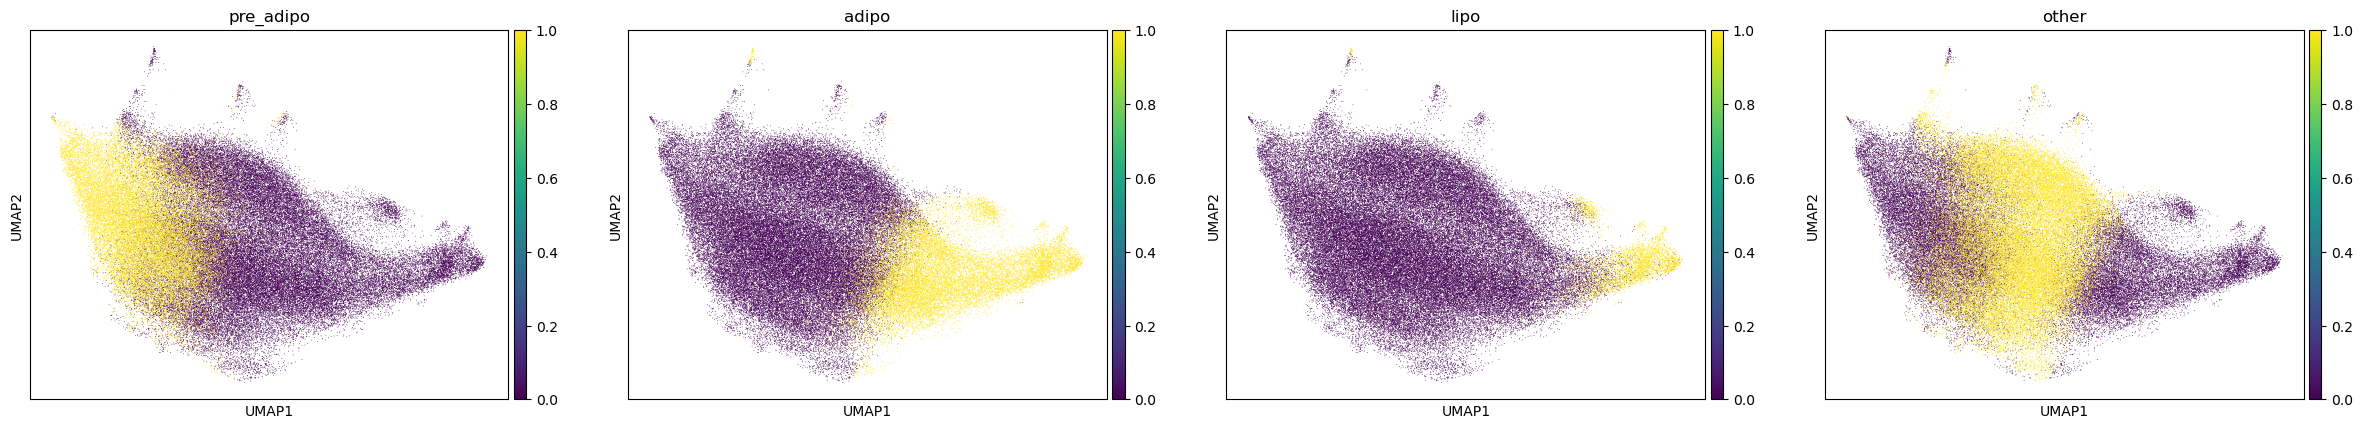

In [5]:
import scanpy as sc

adata_vis = adata_subset.copy()

# 使用 PCA latent
adata_vis.obsm["X_scanvi"] = adata_subset.obsm["X_scanvi"]

sc.pp.neighbors(
    adata_vis,
    use_rep="X_scanvi",
    n_neighbors=30,
    metric="euclidean"
)

sc.tl.umap(
    adata_vis,
    min_dist=0.3
)
sc.pl.umap(
    adata_vis,
    color=[
        "pre_adipo",
        "adipo",
        "lipo",
        "other"
    ],
    cmap="viridis",
    vmin=0,
    vmax=1
)

In [ ]:
import scanpy as sc
import scvi
import numpy as np
import sys
sys.path.append('../')

from scripts.subset_hvg import subset_to_hvg

adata = sc.read_h5ad(
    "../../data/obesity_challenge_2.h5ad"
)

print(adata)

adata_subset, hvg_genes,sig_genes = subset_to_hvg(
    adata,
    hvg_path="../../data/preprocessed/HVG/hvg8000_genes.txt",
    include_signature_genes=True
)

print(adata_subset.var_names)

# load model
scanvi = scvi.model.SCANVI.load(
    "../../resources/scanvi_model_8000",
    adata=adata_subset
)

# mapping
scvi.model.SCANVI.prepare_query_anndata(
    adata_subset,
    scanvi
)

# latent
adata_subset.obsm["X_scanvi"] = (
    scanvi.get_latent_representation(
        adata_subset
    )
)

print("latent shape:")
print(adata_subset.obsm["X_scanvi"].shape)

import sys
sys.path.append('../')
from scripts.pairing import assign_state_label
adata_subset.obs["cell_state"] = assign_state_label(
    adata_subset.obs
)
print(adata_subset.obs["cell_state"].value_counts())

AnnData object with n_obs × n_vars = 90815 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo'
    uns: 'log1p'
    layers: 'counts'
HVG requested: 8000
Signature genes requested: 820
Signature genes used: 512
Total genes used: 8512
Index(['MIR1302-2HG', 'AL669831.2', 'AL645608.4', 'SAMD11', 'HES4',
       'AL645608.1', 'SDF4', 'AL162741.1', 'MXRA8', 'AURKAIP1',
       ...
       'LRG1', 'MB', 'NAPEPLD', 'NUDT7', 'PEX11A', 'PIM1', 'RREB1', 'SLC2A4',
       'SOX13', 'VSTM2A'],
      dtype='object', name='gene', length=8512)


In [9]:

# load model
scanvi = scvi.model.SCANVI.load(
    "../../resources/scanvi_model_8000",
    adata=adata_subset
)

# mapping
scvi.model.SCANVI.prepare_query_anndata(
    adata_subset,
    scanvi
)

# latent
adata_subset.obsm["X_scanvi"] = (
    scanvi.get_latent_representation(
        adata_subset
    )
)

print("latent shape:")
print(adata_subset.obsm["X_scanvi"].shape)

INFO     File ../../resources/scanvi_model_8000/model.pt already downloaded                                        
INFO     Found 100.0% reference vars in query data.                                                                


/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/scvi/model/base/_base_model.py:862: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, device = parse_device_args(


latent shape:
(90815, 50)


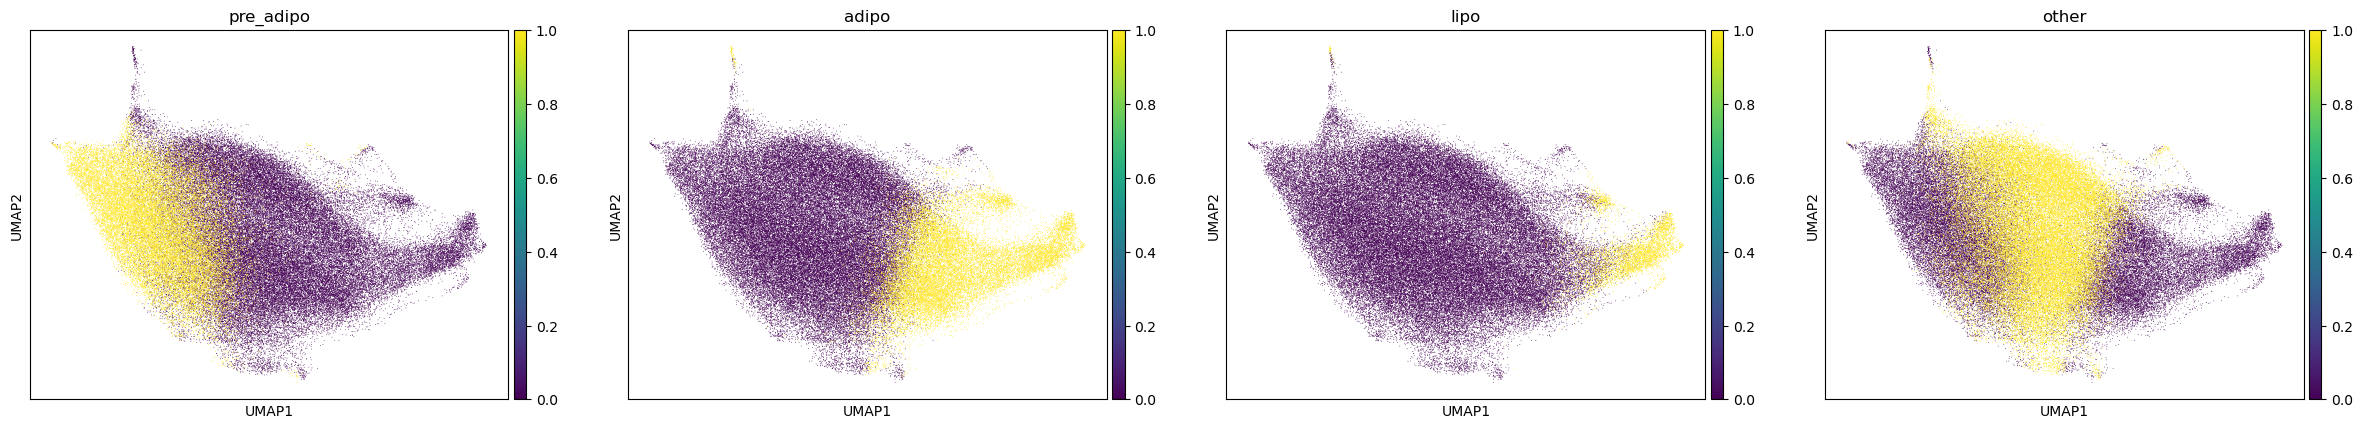

In [10]:
import scanpy as sc

adata_vis = adata_subset.copy()

# 使用 PCA latent
adata_vis.obsm["X_scanvi"] = adata_subset.obsm["X_scanvi"]

sc.pp.neighbors(
    adata_vis,
    use_rep="X_scanvi",
    n_neighbors=30,
    metric="euclidean"
)

sc.tl.umap(
    adata_vis,
    min_dist=0.3
)
sc.pl.umap(
    adata_vis,
    color=[
        "pre_adipo",
        "adipo",
        "lipo",
        "other"
    ],
    cmap="viridis",
    vmin=0,
    vmax=1
)

In [13]:
import scanpy as sc
import scvi
import numpy as np
import sys
sys.path.append('../')

from scripts.subset_hvg import subset_to_hvg

adata = sc.read_h5ad(
    "../../data/obesity_challenge_2.h5ad"
)

print(adata)

adata_subset, hvg_genes,sig_genes = subset_to_hvg(
    adata,
    hvg_path="../../data/preprocessed/HVG/hvg5000_genes.txt",
    include_signature_genes=True
)

print(adata_subset.var_names)


import sys
sys.path.append('../')
from scripts.pairing import assign_state_label
adata_subset.obs["cell_state"] = assign_state_label(
    adata_subset.obs
)
print(adata_subset.obs["cell_state"].value_counts())


# load model
scanvi = scvi.model.SCANVI.load(
    "../../resources/scanvi_model_5000",
    adata=adata_subset
)

# mapping
scvi.model.SCANVI.prepare_query_anndata(
    adata_subset,
    scanvi
)

# latent
adata_subset.obsm["X_scanvi"] = (
    scanvi.get_latent_representation(
        adata_subset
    )
)

print("latent shape:")
print(adata_subset.obsm["X_scanvi"].shape)


AnnData object with n_obs × n_vars = 90815 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo'
    uns: 'log1p'
    layers: 'counts'
HVG requested: 5000
Signature genes requested: 820
Signature genes used: 563
Total genes used: 5563
Index(['MIR1302-2HG', 'AL669831.2', 'AL645608.4', 'SAMD11', 'SDF4',
       'AL162741.1', 'MXRA8', 'AURKAIP1', 'MRPL20', 'AL391244.1',
       ...
       'MB', 'NAPEPLD', 'NUDT7', 'PEX11A', 'PIM1', 'RGS2', 'RREB1', 'SLC2A4',
       'SOX13', 'VSTM2A'],
      dtype='object', name='gene', length=5563)
cell_state
other         43319
pre_adipo     26681
adipo         16057
lipo_adipo     4758
Name: count, dtype: int64
INFO     File ../../resources/scanvi_model_5000/model.pt already downloaded                                        
INFO     Found 100.0% reference vars in query data.                                 

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/scvi/model/base/_base_model.py:862: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, device = parse_device_args(


latent shape:
(90815, 50)


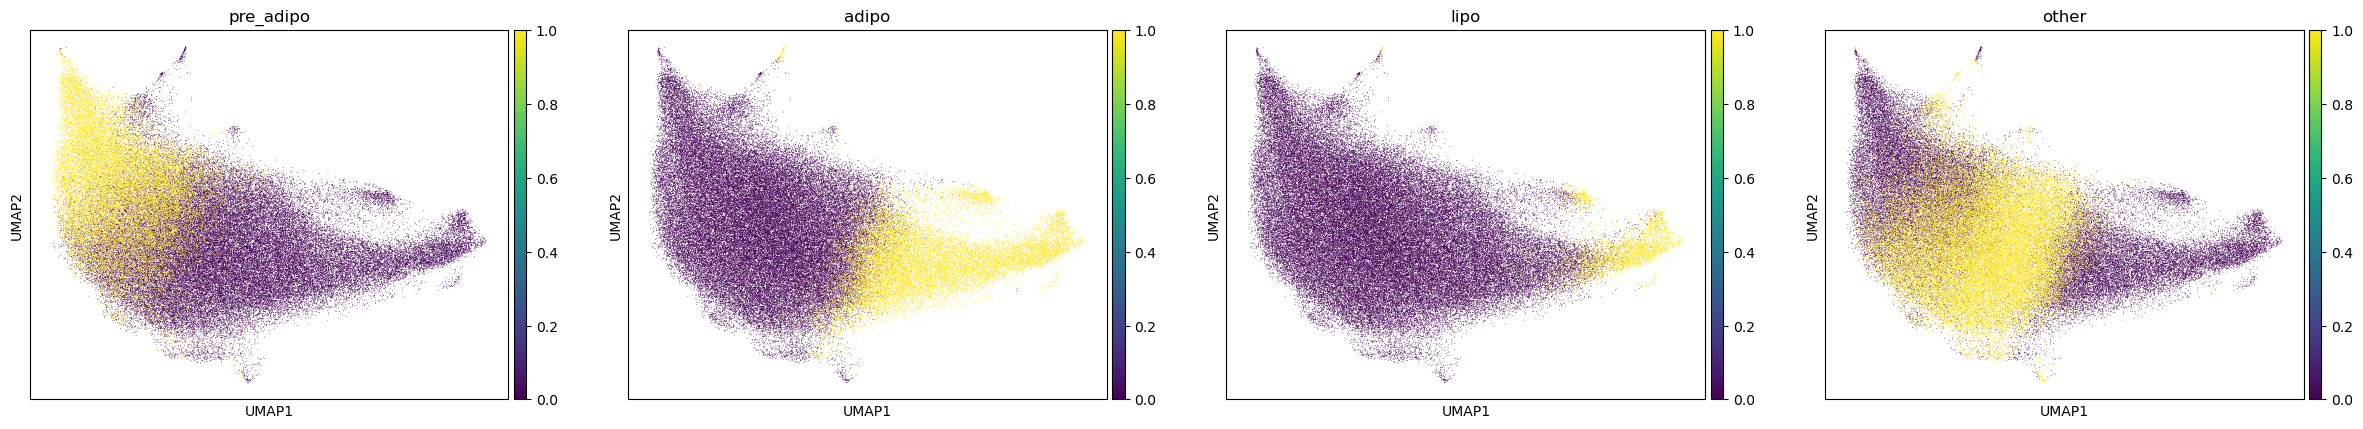

In [14]:
import scanpy as sc

adata_vis = adata_subset.copy()

# 使用 PCA latent
adata_vis.obsm["X_scanvi"] = adata_subset.obsm["X_scanvi"]

sc.pp.neighbors(
    adata_vis,
    use_rep="X_scanvi",
    n_neighbors=30,
    metric="euclidean"
)

sc.tl.umap(
    adata_vis,
    min_dist=0.3
)
sc.pl.umap(
    adata_vis,
    color=[
        "pre_adipo",
        "adipo",
        "lipo",
        "other"
    ],
    cmap="viridis",
    vmin=0,
    vmax=1
)

In [15]:
adata_vis

AnnData object with n_obs × n_vars = 90815 × 5563
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo', 'cell_state', '_scvi_batch', '_scvi_labels'
    uns: 'log1p', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap'
    obsm: 'X_scanvi', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

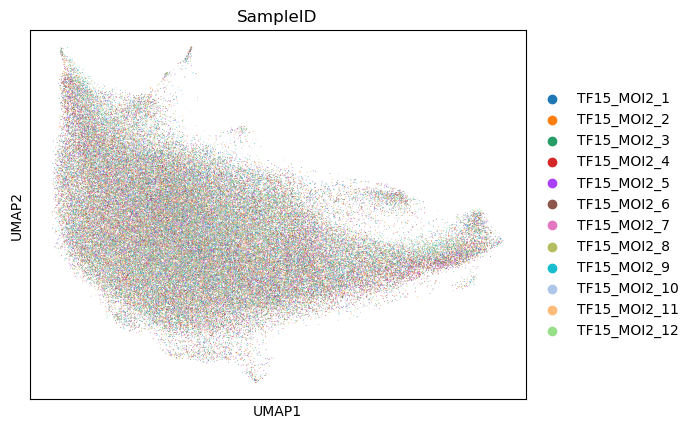

In [18]:
sc.pl.umap(
    adata_vis,
    color="SampleID"
)